# 02. Machine Learning Modeling & Evaluation
**Project:** Predicting Football Player Market Values  
**Author:** Khaled Blel (4 Data Science 2)  

In this notebook, we build and evaluate machine learning models to predict `log_market_value`.
To ensure a rigorous methodology, we will:
1.  Perform a **Time-Based Train/Test Split** to prevent temporal data leakage.
2.  Build a **Scikit-Learn Preprocessing Pipeline** (Target Encoding for high-cardinality features, One-Hot Encoding for low-cardinality, and StandardScaler for numericals).
3.  Train and tune at least 3 models (Ridge, Decision Tree, Random Forest/XGBoost) using **Cross-Validation**.

## 0. Install Dependencies & Import Libraries


In [1]:
# ==========================================
# 1. Environment Setup
# ==========================================
!pip install category_encoders -q

# ==========================================
# 2. Standard Library Imports
# ==========================================
import os
import time
import warnings

# ==========================================
# 3. Data Manipulation & Visualization
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 4. Machine Learning: Preprocessing & Pipelines
# ==========================================
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from category_encoders import TargetEncoder

# ==========================================
# 5. Machine Learning: Model Selection & Metrics
# ==========================================
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==========================================
# 6. Machine Learning: Algorithms / Models
# ==========================================
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

# ==========================================
# 7. Model Saving & Serialization
# ==========================================
import joblib

# ==========================================
# 8. Global Configurations
# ==========================================
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 6.3 MB/s eta 0:00:00
Libraries imported successfully!


---
## 1. Data Loading & Time-Based Split (Out-of-Time Validation)

If we randomly split our dataset, the model might train on a player's valuation from 2026 and use it to predict their valuation in 2024. This is "Temporal Leakage."

Since our dataset spans multiple years up to 2026, we will sort the data chronologically by `date`. To ensure a robust evaluation while keeping maximum training volume, we dynamically calculate a **90/10 split**: the first 90% of historical records will form our Training Set, and the most recent 10% will be our Test Set.

In [2]:
# 1. Load the dataset
df = pd.read_csv("eda_final_dataset.csv")

# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])

# 2. Sort chronologically. This is vital for a time-based split.
df = df.sort_values('date').reset_index(drop=True)

# 3. Define our features (X) and target (y)
cols_to_drop =['player_id', 'date', 'market_value_in_eur', 'log_market_value']
X = df.drop(columns=cols_to_drop)
y = df['log_market_value']

# 4. Programmatically find the date that gives us exactly an 90/10 split
split_index = int(len(df) * 0.90)
split_date = df['date'].iloc[split_index]
print(f"Calculated Split Date to achieve 90/10: {split_date.strftime('%Y-%m-%d')}")

# 5. Perform the Time-Based Split
# Everything before split_date is Train, everything on or after is Test
train_mask = df['date'] < split_date
test_mask = df['date'] >= split_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

# Keep the actual euro values for the test set
y_test_euros = df.loc[test_mask, 'market_value_in_eur']

print(f"Total dataset size: {len(df)} rows")
print(f"Training Set: {len(X_train)} rows ({(len(X_train)/len(df))*100:.1f}%)")
print(f"Test Set: {len(X_test)} rows ({(len(X_test)/len(df))*100:.1f}%)")

Calculated Split Date to achieve 90/10: 2024-06-06
Total dataset size: 316103 rows
Training Set: 283891 rows (89.8%)
Test Set: 32212 rows (10.2%)


---
## 2. Feature Engineering Pipeline: Scaling & Encoding
To prepare our features for machine learning, we must transform them into a format that algorithms can understand, while strictly avoiding data leakage from our test set. We use `ColumnTransformer` to apply different strategies to different types of columns:

1.  **StandardScaler (Numerical Features):** Centers data around 0 with a standard deviation of 1. Crucial for linear models (Ridge/Lasso) so that features with large ranges (like `career_minutes_played`) don't overpower features with small ranges (like `career_goals`).
2.  **One-Hot Encoding (Low-Cardinality Categorical):** For features with few unique values (`position`, `sub_position`, `foot`, `is_major_national_league`), we create binary dummy columns.
3.  **Target Encoding (High-Cardinality Categorical):** For features with hundreds of unique values (`current_club_id`, `country_of_citizenship`, `country_name`), One-Hot Encoding would create massive dimensionality, slowing down models and causing overfitting. Instead, we replace the category with the *average `log_market_value`* of that category (learned strictly from the training set).

In [3]:
# 1. Define feature groups based on our EDA findings
# High Cardinality (Target Encoding)
high_card_cols =['current_club_id', 'country_of_citizenship', 'country_name']

# Low Cardinality (One-Hot Encoding)
# We cast is_major_national_league to string so the encoder treats it as categorical
X_train['is_major_national_league'] = X_train['is_major_national_league'].astype(str)
X_test['is_major_national_league'] = X_test['is_major_national_league'].astype(str)
low_card_cols =['position', 'sub_position', 'foot', 'is_major_national_league']

# Numerical (Standard Scaling)
num_cols =[
    'height_in_cm', 'age_at_valuation', 'valuation_year',
    'career_minutes_played', 'career_goals', 'career_assists',
    'career_yellow_cards', 'career_red_cards',
    'recent_365d_minutes_played', 'recent_365d_goals', 'recent_365d_assists',
    'recent_365d_yellow_cards', 'recent_365d_red_cards'
]

# 2. Instantiate the encoders and scalers
target_encoder = TargetEncoder(smoothing=10.0) # Smoothing prevents overfitting on rare clubs/countries
ohe_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
scaler = StandardScaler()

# 3. Combine them into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, num_cols),
        ('cat_high', target_encoder, high_card_cols),
        ('cat_low', ohe_encoder, low_card_cols)
    ],
    remainder='drop'
)

# 4. Fit the preprocessor on the training data and transform both sets
print("Fitting preprocessor on training data...")
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

# 5. Printing new shape of our data
print(f"Original Training Shape: {X_train.shape}")
print(f"Processed Training Shape: {X_train_processed.shape}")

Fitting preprocessor on training data...
Original Training Shape: (283891, 20)
Processed Training Shape: (283891, 38)


---
## 3. Model Training & Evaluation: Linear Baselines (Ridge & Lasso)
We begin with regularized linear models to establish a baseline.
*   **Why Regularization?** Features like `career_goals` and `recent_365d_goals` are highly correlated (multicollinearity). Standard Linear Regression would struggle here.
*   **Ridge (L2)** shrinks the coefficients of less important features.
*   **Lasso (L1)** can shrink coefficients exactly to zero, performing automatic feature selection.

We use Cross-Validation (`RidgeCV` and `LassoCV`) to automatically tune the `alpha` (regularization strength) hyperparameter. Finally, we evaluate using MAE, RMSE, and $R^2$. We will also convert the log predictions back to actual Euros to understand the real-world financial error.

In [4]:
# @title Define Evaluation Function

# 1. Helper function to evaluate models
def evaluate_model(model_name, y_true_log, y_pred_log, y_true_eur):
    # Calculate metrics in Log Space
    r2 = r2_score(y_true_log, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae_log = mean_absolute_error(y_true_log, y_pred_log)

    # Calculate metrics in Euro Space
    y_pred_eur = np.expm1(y_pred_log)
    mae_eur = mean_absolute_error(y_true_eur, y_pred_eur)

    print(f"--- {model_name} Performance ---")
    print(f"R² Score (Explained Variance): {r2:.4f}")
    print(f"RMSE (Log Space): {rmse_log:.4f}")
    print(f"MAE (Log Space): {mae_log:.4f}")
    print(f"Mean Absolute Error (Euros): €{mae_eur:,.0f}\n")

    return {'Model': model_name, 'R2': r2, 'RMSE_Log': rmse_log, 'MAE_Eur': mae_eur}

results_list =[]

In [5]:
# @title Train Linear Models (Ridge/Lasso)

# ==========================================
# 2. Train Ridge Regression (L2 Penalty)
# ==========================================
print("Training Ridge Regression via Cross-Validation...")
start_time = time.time()

alphas_ridge =[0.1, 1.0, 10.0, 100.0]
ridge_model = RidgeCV(alphas=alphas_ridge, cv=5)
ridge_model.fit(X_train_processed, y_train)

ridge_preds = ridge_model.predict(X_test_processed)
ridge_time = time.time() - start_time

print(f"Ridge completed in {ridge_time:.2f} seconds. Best Alpha: {ridge_model.alpha_}")
res_ridge = evaluate_model("Ridge Regression", y_test, ridge_preds, y_test_euros)
results_list.append(res_ridge)


# ==========================================
# 3. Train Lasso Regression (L1 Penalty)
# ==========================================
print("Training Lasso Regression via Cross-Validation...")
start_time = time.time()

alphas_lasso = [0.001, 0.01, 0.1, 1.0]
lasso_model = LassoCV(alphas=alphas_lasso, cv=5, random_state=42, max_iter=2000)
lasso_model.fit(X_train_processed, y_train)

lasso_preds = lasso_model.predict(X_test_processed)
lasso_time = time.time() - start_time

print(f"Lasso completed in {lasso_time:.2f} seconds. Best Alpha: {lasso_model.alpha_}")
res_lasso = evaluate_model("Lasso Regression", y_test, lasso_preds, y_test_euros)
results_list.append(res_lasso)

Training Ridge Regression via Cross-Validation...
Ridge completed in 10.92 seconds. Best Alpha: 100.0
--- Ridge Regression Performance ---
R² Score (Explained Variance): 0.5631
RMSE (Log Space): 1.0923
MAE (Log Space): 0.8726
Mean Absolute Error (Euros): €4,632,189

Training Lasso Regression via Cross-Validation...
Lasso completed in 1.84 seconds. Best Alpha: 0.01
--- Lasso Regression Performance ---
R² Score (Explained Variance): 0.5640
RMSE (Log Space): 1.0912
MAE (Log Space): 0.8707
Mean Absolute Error (Euros): €4,630,556



---
## 4. Model Training & Tuning: Random Forest Regressor
While Ridge and Lasso provided a solid baseline, they struggle with non-linear relationships (like the "Aging Curve" where value peaks at 27 and then drops).

Tree-based ensemble models like Random Forest handle non-linearity natively by splitting the data into branches. To optimize the model without spending hours on computation, we use `RandomizedSearchCV` (with 3-fold Cross-Validation) to tune hyperparameters such as the maximum depth of the trees and the number of estimators.

In [6]:
print("Starting RandomizedSearchCV for Random Forest...")
start_time = time.time()

# 1. Define the base model
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# 2. Define the Hyperparameter Grid to search
param_dist_rf = {
    'n_estimators': [100, 200],
    'max_depth': [15, 25, None],
    'min_samples_split': [5, 15, 50],
    'max_features': ['sqrt', 'log2', 1.0]
}

# 3. Set up RandomizedSearchCV
rf_random = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=5,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 4. Fit the model
rf_random.fit(X_train_processed, y_train)

# 5. Make predictions with the best model found
rf_best = rf_random.best_estimator_
rf_preds = rf_best.predict(X_test_processed)
rf_time = time.time() - start_time

print(f"\nRandom Forest Tuning completed in {rf_time/60:.2f} minutes.")
print(f"Best Hyperparameters Found: {rf_random.best_params_}")

# 6. Evaluate
res_rf = evaluate_model("Random Forest", y_test, rf_preds, y_test_euros)
results_list.append(res_rf)

Starting RandomizedSearchCV for Random Forest...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Random Forest Tuning completed in 39.89 minutes.
Best Hyperparameters Found: {'n_estimators': 200, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': 25}
--- Random Forest Performance ---
R² Score (Explained Variance): 0.7733
RMSE (Log Space): 0.7868
MAE (Log Space): 0.6049
Mean Absolute Error (Euros): €2,991,016



---
## 5. Model Training & Tuning: XGBoost
For our next model, we use Extreme Gradient Boosting (XGBoost). Unlike Random Forest, which builds deep trees independently, XGBoost builds shallow trees sequentially—each new tree corrects the errors made by the previous ones.

In [7]:
print("Starting RandomizedSearchCV for XGBoost...")
start_time = time.time()

# 1. Base Model
xgb_base = xgb.XGBRegressor(
    tree_method='hist',
    device='cuda',
    objective='reg:squarederror',
    random_state=42
)

# 2. Hyperparameter Grid
param_dist_xgb_deep = {
    'n_estimators': [300, 500, 800, 1000],
    'learning_rate':[0.01, 0.03, 0.05, 0.1, 0.2],
    'max_depth': [5, 7, 9, 11, 13],
    'subsample':[0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':[0.7, 0.8, 0.9, 1.0],
    'min_child_weight':[1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.5]
}

# 3. Setup RandomizedSearchCV with 50 iterations (150 fits)
xgb_random_deep = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb_deep,
    n_iter=50,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=2,
    random_state=42
)

# 4. Fit the model
xgb_random_deep.fit(X_train_processed, y_train)

# 5. Extract the best model
xgb_best = xgb_random_deep.best_estimator_
xgb_preds = xgb_best.predict(X_test_processed)

xgb_time = time.time() - start_time

print(f"\nXGBoost Tuning completed in {xgb_time/60:.2f} minutes.")
print(f"Best Hyperparameters Found: {xgb_random_deep.best_params_}")

results_list = [res for res in results_list if res['Model'] != "XGBoost"]

# 7. Evaluate and save the new results
res_xgb_deep = evaluate_model("XGBoost", y_test, xgb_preds, y_test_euros)
results_list.append(res_xgb_deep)

Starting RandomizedSearchCV for XGBoost...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END colsample_bytree=1.0, gamma=0.2, learning_rate=0.1, max_depth=13, min_child_weight=5, n_estimators=500, subsample=0.9; total time=   7.2s
[CV] END colsample_bytree=1.0, gamma=0.2, learning_rate=0.1, max_depth=13, min_child_weight=5, n_estimators=500, subsample=0.9; total time=   5.9s
[CV] END colsample_bytree=1.0, gamma=0.2, learning_rate=0.1, max_depth=13, min_child_weight=5, n_estimators=500, subsample=0.9; total time=   5.8s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.2, max_depth=7, min_child_weight=7, n_estimators=300, subsample=1.0; total time=   1.6s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.2, max_depth=7, min_child_weight=7, n_estimators=300, subsample=1.0; total time=   1.8s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.2, max_depth=7, min_child_weight=7, n_estimators=300, subsample=1.0; total time=   2.0s
[CV] END colsamp

---
## 6. Model Training & Tuning: LightGBM
To ensure a comprehensive evaluation of ensemble methods, we introduce Microsoft's LightGBM.
While XGBoost grows trees level-wise, LightGBM grows them leaf-wise. This often allows it to converge on complex patterns (like our highly skewed market values) faster and sometimes with greater accuracy.

We will tune critical parameters like `num_leaves` which is the main complexity control in LightGBM.

In [8]:
print("Starting RandomizedSearchCV for LightGBM...")
start_time = time.time()

# 1. Base Model
lgb_base = lgb.LGBMRegressor(
    device='gpu',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# 2. Hyperparameter Grid
param_dist_lgb = {
    'n_estimators': [300, 500, 800, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves':[31, 63, 127, 255],
    'max_depth':[-1, 7, 9, 11],
    'subsample':[0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_samples':[10, 20, 50, 100]
}

# 3. Setup RandomizedSearchCV with 50 iterations (150 fits)
lgb_random = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_dist_lgb,
    n_iter=50,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=2,
    random_state=42
)

# 4. Fit the model
lgb_random.fit(X_train_processed, y_train)

# 5. Extract the best model
lgb_best = lgb_random.best_estimator_
lgb_preds = lgb_best.predict(X_test_processed)

lgb_time = time.time() - start_time

print(f"\nLightGBM Tuning completed in {lgb_time/60:.2f} minutes.")
print(f"Best Hyperparameters Found: {lgb_random.best_params_}")

# 6. Evaluate and save the results
res_lgb = evaluate_model("LightGBM", y_test, lgb_preds, y_test_euros)
results_list.append(res_lgb)

Starting RandomizedSearchCV for LightGBM...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END colsample_bytree=0.9, learning_rate=0.05, max_depth=-1, min_child_samples=20, n_estimators=800, num_leaves=63, subsample=0.9; total time=  23.0s
[CV] END colsample_bytree=0.9, learning_rate=0.05, max_depth=-1, min_child_samples=20, n_estimators=800, num_leaves=63, subsample=0.9; total time=  17.3s
[CV] END colsample_bytree=0.9, learning_rate=0.05, max_depth=-1, min_child_samples=20, n_estimators=800, num_leaves=63, subsample=0.9; total time=  17.5s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=11, min_child_samples=20, n_estimators=500, num_leaves=255, subsample=0.7; total time=  28.9s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=11, min_child_samples=20, n_estimators=500, num_leaves=255, subsample=0.7; total time=  29.6s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=11, min_child_samples=20, n_estimators=500, num_leaves=255, s

---
## 7. Model Comparison & Selection
We have trained five distinct machine learning algorithms:
*   **Linear Baseline:** Ridge (L2) and Lasso (L1)
*   **Bagging Ensemble:** Random Forest
*   **Boosting Ensembles:** XGBoost and LightGBM

To determine the best model for deployment, we will visualize their performance across two key metrics:
1.  **$R^2$ Score (Explained Variance):** How well the model captures the overall variance in the log-transformed market.
2.  **Mean Absolute Error (Euros):** The average real-world financial error when predicting a player's price tag.

,Model,R2,RMSE_Log,MAE_Eur
0,XGBoost,0.837127,0.666936,2.194802e+06
1,LightGBM,0.834397,0.672503,2.147641e+06
2,Random Forest,0.773341,0.786768,2.991016e+06
3,Lasso Regression,0.564003,1.091194,4.630556e+06
4,Ridge Regression,0.563149,1.092261,4.632189e+06


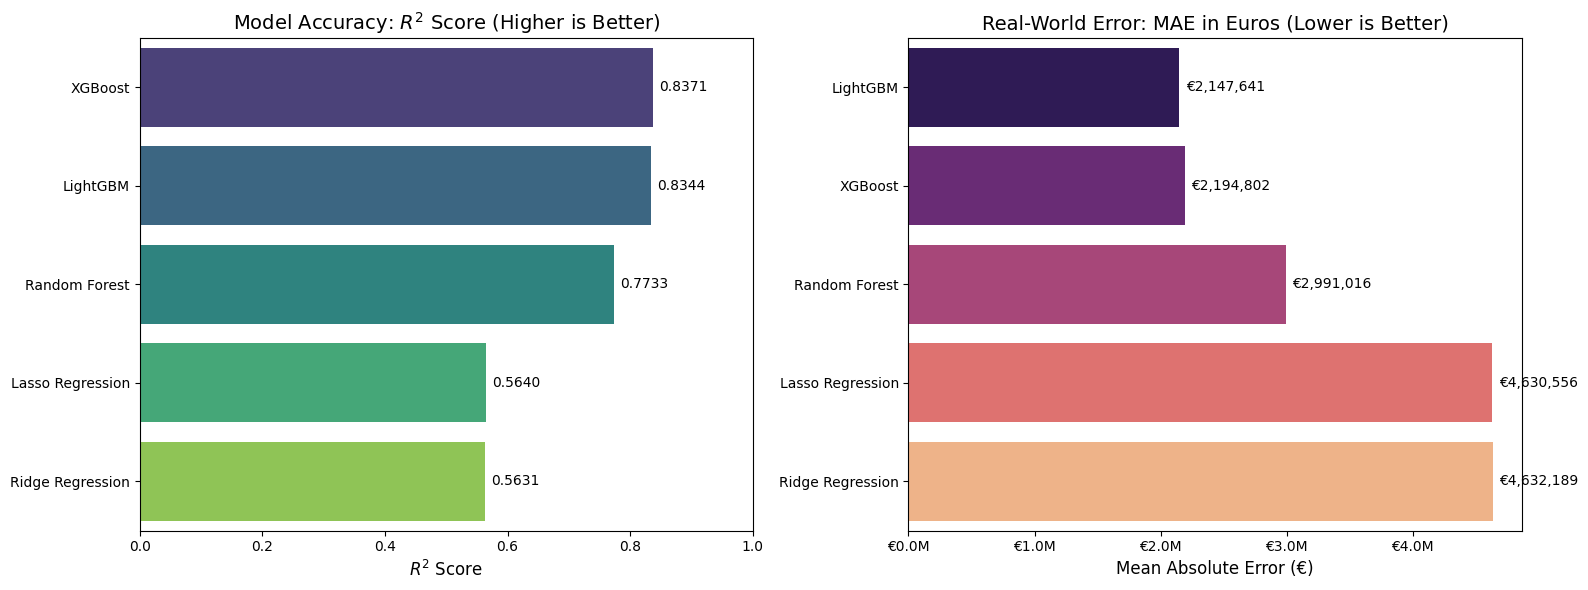

In [9]:
# 1. Convert our results list into a Pandas DataFrame
results_df = pd.DataFrame(results_list)
# Sort by R2 Score (Highest to Lowest)
results_df = results_df.sort_values(by='R2', ascending=False).reset_index(drop=True)

display(results_df)

# 2. Set up the matplotlib figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: R-Squared Score ---
sns.barplot(
    data=results_df,
    x='R2',
    y='Model',
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title('Model Accuracy: $R^2$ Score (Higher is Better)', fontsize=14)
axes[0].set_xlabel('$R^2$ Score', fontsize=12)
axes[0].set_ylabel('')
axes[0].set_xlim(0, 1.0)

for i, v in enumerate(results_df['R2']):
    axes[0].text(v + 0.01, i, f"{v:.4f}", color='black', va='center')

# --- Plot 2: Mean Absolute Error ---
results_df_mae = results_df.sort_values(by='MAE_Eur', ascending=True).reset_index(drop=True)

sns.barplot(
    data=results_df_mae,
    x='MAE_Eur',
    y='Model',
    palette='magma',
    ax=axes[1]
)
axes[1].set_title('Real-World Error: MAE in Euros (Lower is Better)', fontsize=14)
axes[1].set_xlabel('Mean Absolute Error (€)', fontsize=12)
axes[1].set_ylabel('')

# Format x-axis to show millions
def format_millions(x, pos):
    return f'€{x*1e-6:.1f}M'
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(format_millions))

# Add value labels
for i, v in enumerate(results_df_mae['MAE_Eur']):
    axes[1].text(v + 50000, i, f"€{v:,.0f}", color='black', va='center')

plt.tight_layout()
plt.show()

---
## 8. Interpretability: Feature Importance
To trust our champion model, we need to understand which features drive its predictions.

Because we used a Scikit-Learn `ColumnTransformer`, our feature names were transformed (especially via One-Hot Encoding). We will first extract the exact feature names from the pipeline, map them to our models's `feature_importances_` array, and visualize the Top 15 most influential factors in determining a player's market value.

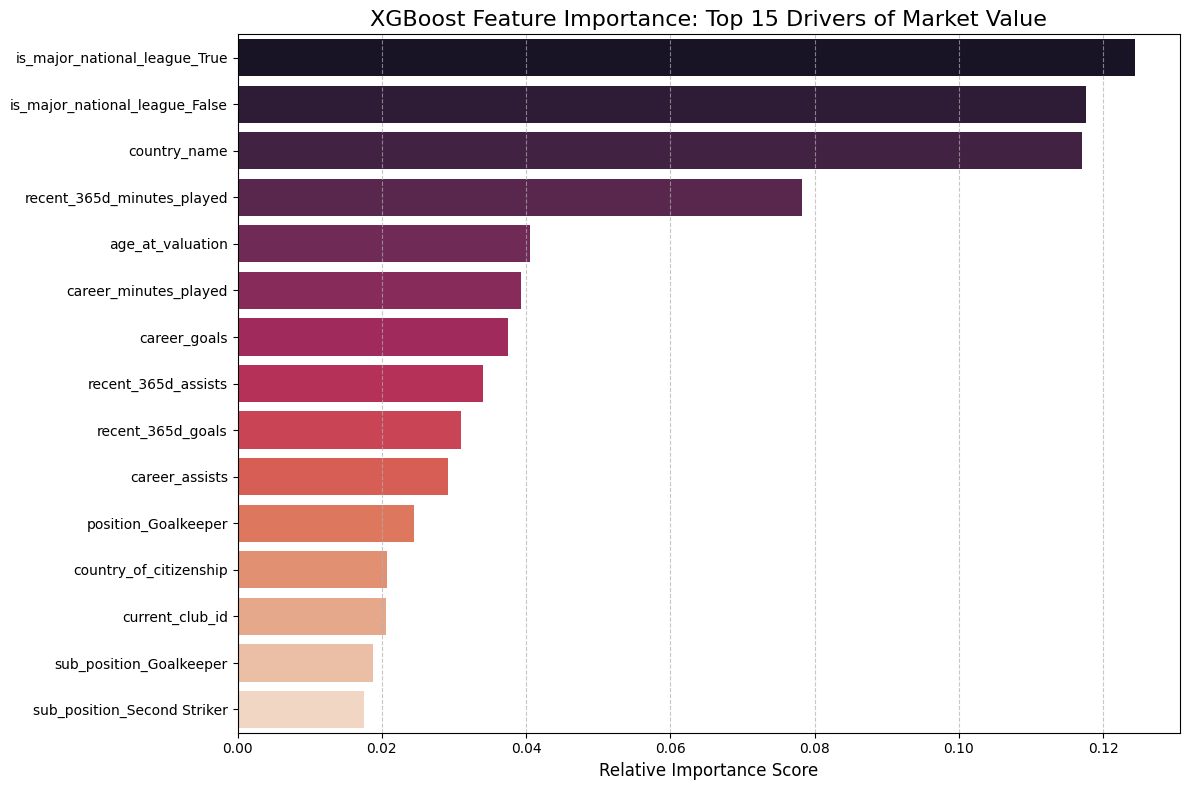


Top 3 Most Important Features:
- is_major_national_league_True (0.1244)
- is_major_national_league_False (0.1177)
- country_name (0.1171)


In [10]:
# 1. Extract Feature Names from the Preprocessor Pipeline

num_features = num_cols
target_features = high_card_cols
ohe_features = preprocessor.named_transformers_['cat_low'].get_feature_names_out(low_card_cols)
all_feature_names = np.concatenate([num_features, target_features, ohe_features])

# 2. Get the importance scores from our champion model
importances = xgb_best.feature_importances_

# 3. Create a DataFrame for easy sorting and plotting
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
})

# Sort by importance and grab the Top 15
top_15_features = importance_df.sort_values(by='Importance', ascending=False).head(15)

# 4. Plot the Feature Importances
plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_15_features,
    x='Importance',
    y='Feature',
    palette='rocket'
)

plt.title('XGBoost Feature Importance: Top 15 Drivers of Market Value', fontsize=16)
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print the top 3 for a quick summary
print("\nTop 3 Most Important Features:")
for i, row in top_15_features.head(3).iterrows():
    print(f"- {row['Feature']} ({row['Importance']:.4f})")

---
## 9. Error Analysis: Residual Inspection
To understand our model's performance, we must analyze its errors (residuals).
A residual is the difference between the actual `log_market_value` and our predicted `log_market_value`.

By plotting **Actual vs. Predicted** values, we can identify patterns in our errors:
*   Does the model systematically undervalue superstars?
*   Does it overvalue older players?
*   Are the errors normally distributed around zero? (Which indicates a healthy, unbiased model).

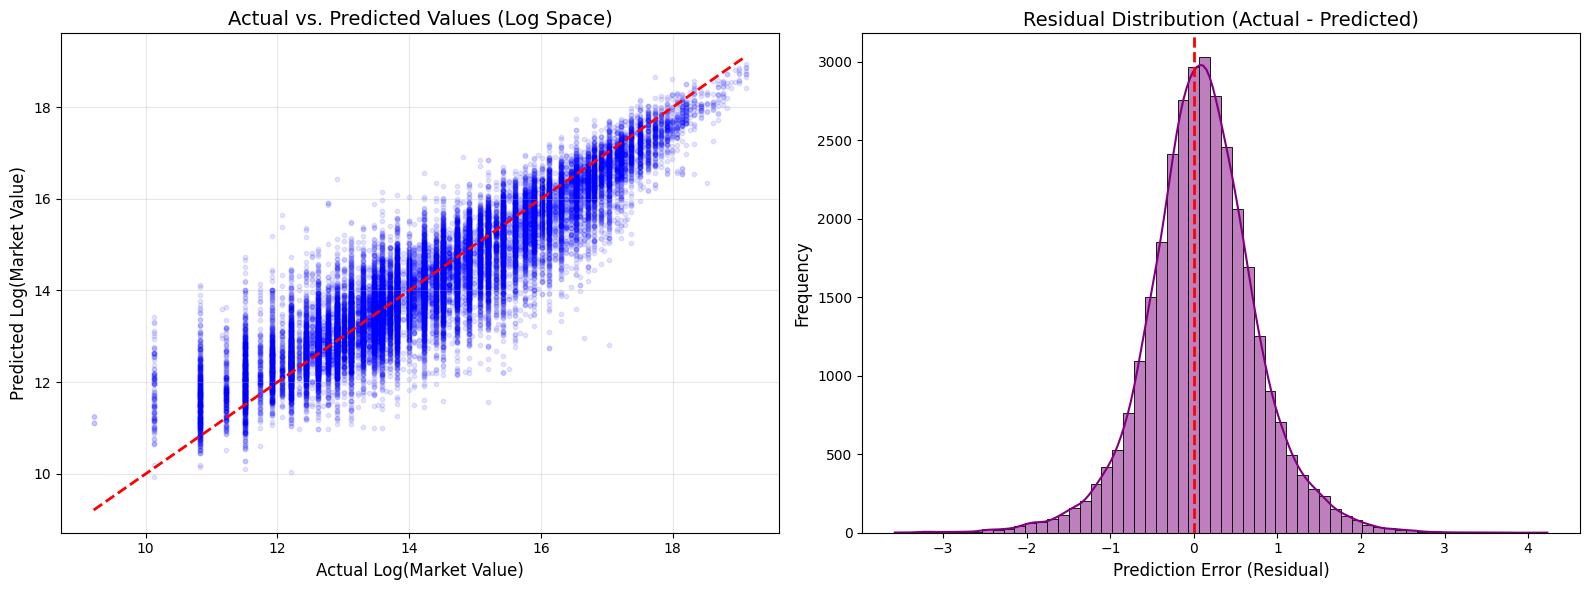

--- Error Analysis Summary ---
Max Overestimation (Log): -3.58 (Model guessed way too high)
Max Underestimation (Log): 4.23 (Model guessed way too low)


In [11]:
# 1. Calculate the residuals (Actual - Predicted)
residuals = y_test - xgb_preds

# 2. Set up the plotting area
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Actual vs. Predicted (Scatter) ---
axes[0].scatter(y_test, xgb_preds, alpha=0.1, color='blue', s=10)

# Add a perfect prediction diagonal line (y = x)
min_val = min(y_test.min(), xgb_preds.min())
max_val = max(y_test.max(), xgb_preds.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

axes[0].set_title('Actual vs. Predicted Values (Log Space)', fontsize=14)
axes[0].set_xlabel('Actual Log(Market Value)', fontsize=12)
axes[0].set_ylabel('Predicted Log(Market Value)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Residual Distribution (Histogram) ---
sns.histplot(residuals, bins=60, kde=True, ax=axes[1], color='purple')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)

axes[1].set_title('Residual Distribution (Actual - Predicted)', fontsize=14)
axes[1].set_xlabel('Prediction Error (Residual)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

# 3. Print a quick summary of the errors
print("--- Error Analysis Summary ---")
print(f"Max Overestimation (Log): {residuals.min():.2f} (Model guessed way too high)")
print(f"Max Underestimation (Log): {residuals.max():.2f} (Model guessed way too low)")

---
## 10. Model Export & Deployment Preparation
We have officially selected **XGBoost** as our champion model ($R^2 = 0.8xxxx$).

To satisfy the deployment requirement of our project, we will deploy this model via a Streamlit web application. For the app to function, it needs to process new user inputs exactly as we processed our training data.

Therefore, we export two artifacts using `joblib`:
1.  **The Preprocessor Pipeline:** Contains the fitted Target Encoders (for clubs/nationalities), One-Hot Encoders (for positions), and Standard Scalers.
2.  **The XGBoost Model:** The deeply tuned champion model.

In [12]:
print("Exporting ML artifacts for deployment...")

# 1. Create a directory to store our models if it doesn't exist
os.makedirs("models", exist_ok=True)

# 2. Save the fitted preprocessor
preprocessor_path = "models/preprocessor.joblib"
joblib.dump(preprocessor, preprocessor_path)
print(f"Preprocessor successfully saved to: {preprocessor_path}")

# 3. Save the champion XGBoost model
champion_model_path = "models/xgboost_champion.joblib"
joblib.dump(xgb_best, champion_model_path)
print(f"Champion XGBoost model successfully saved to: {champion_model_path}")

Exporting ML artifacts for deployment...
Preprocessor successfully saved to: models/preprocessor.joblib
Champion XGBoost model successfully saved to: models/xgboost_champion.joblib
